####Aim

The aim of this experiment is to implement and understand two fundamental Convolutional Neural Network (CNN) architectures, namely LeNet-5 and AlexNet, for image classification tasks, and to analyze their performance on standard datasets.

####Goals

The first goal of this assignment is to investigate the principles of operation of CNNs and learn about the working methods used by deep learning algorithms while processing images. The second goal of the experiment is to build the LeNet-5 model and analyze the performance of simple CNN architectures on the simple dataset. Lastly, the goal is to build the AlexNet CNN, a much more complex deep learning architecture and compare it to LeNet.

####Theory (a)

Convolutional Neural Networks (CNNs) are a class of deep learning models specifically designed for processing structured grid data such as images. They consist of multiple layers including convolutional layers, pooling layers, and fully connected layers. The convolutional layers extract spatial features using filters, while pooling layers reduce dimensionality and help in generalization. Fully connected layers perform classification based on extracted features.

LeNet-5, proposed by Yann LeCun in 1998, is one of the earliest CNN architectures designed for handwritten digit recognition. It consists of alternating convolutional and pooling layers followed by fully connected layers. It is simple yet effective for low-resolution grayscale images.

In [ ]:
import tensorflow as tf
print("tensorflow version: ", tf.__version__)

tensorflow version:  2.19.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("x_train shape: ", x_train.shape)
print("y_train shape: ", y_train.shape)
print("x_test shape: ", x_test.shape)
print("y_test shape: ", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape:  (60000, 28, 28)
y_train shape:  (60000,)
x_test shape:  (10000, 28, 28)
y_test shape:  (10000,)


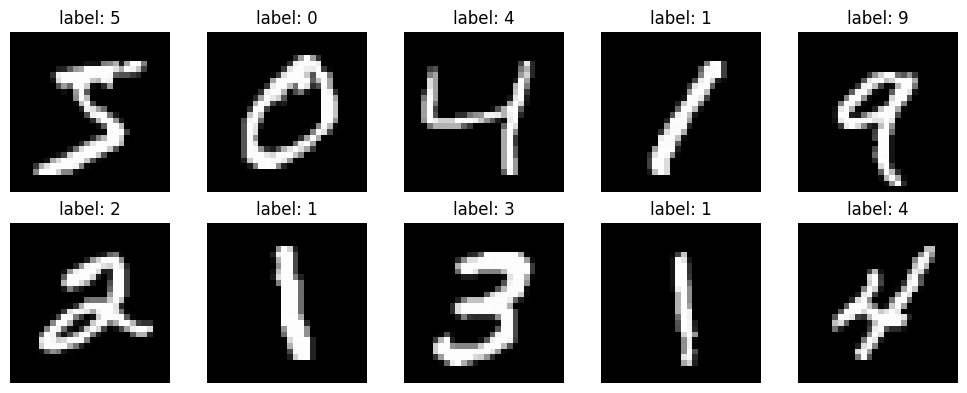

In [ ]:
plt.figure(figsize = (10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i], cmap = "gray")
  plt.title(f"label: {y_train[i]}")
  plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
x_train = np.expand_dims(x_train, axis = -1)
x_test = np.expand_dims(x_test, axis = -1)

x_train = tf.image.resize(x_train, [32, 32]).numpy()
x_test = tf.image.resize(x_test, [32, 32]).numpy()

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("new x_train shape: ", x_train.shape)
print("new x_test shape: ", x_test.shape)
print("new y_train shape: ", y_train_cat.shape)
print("new y_test shape: ", y_test_cat.shape)

new x_train shape:  (60000, 32, 32, 1)
new x_test shape:  (10000, 32, 32, 1)
new y_train shape:  (60000, 10)
new y_test shape:  (10000, 10)


In [ ]:
lenet5 = models.Sequential()

lenet5.add(layers.Input(shape = (32, 32, 1)))
lenet5.add(layers.Conv2D(filters = 6, kernel_size = (5, 5), activation = "tanh"))
lenet5.add(layers.AveragePooling2D(pool_size = (2, 2), strides = 2))
lenet5.add(layers.Conv2D(filters = 16, kernel_size = (5, 5), activation = "tanh"))
lenet5.add(layers.AveragePooling2D(pool_size = (2, 2), strides = 2))
lenet5.add(layers.Flatten())

lenet5.add(layers.Dense(120, activation = "tanh"))
lenet5.add(layers.Dense(84, activation = "tanh"))

#output
lenet5.add(layers.Dense(10, activation = "softmax"))

In [ ]:
lenet5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lenet5.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [ ]:
history_lenet5 = lenet5.fit(x_train, y_train_cat, epochs = 5, batch_size = 128, validation_split = 0.1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8987 - loss: 0.3475 - val_accuracy: 0.9652 - val_loss: 0.1274
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9632 - loss: 0.1218 - val_accuracy: 0.9737 - val_loss: 0.0921
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9766 - loss: 0.0779 - val_accuracy: 0.9800 - val_loss: 0.0670
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9825 - loss: 0.0574 - val_accuracy: 0.9800 - val_loss: 0.0626
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9859 - loss: 0.0452 - val_accuracy: 0.9840 - val_loss: 0.0516


In [ ]:
test_loss, test_acc = lenet5.evaluate(x_test, y_test_cat)
print("test loss: ", test_loss)
print("test accuracy: ", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9844 - loss: 0.0519
test loss:  0.0518670529127121
test accuracy:  0.9843999743461609


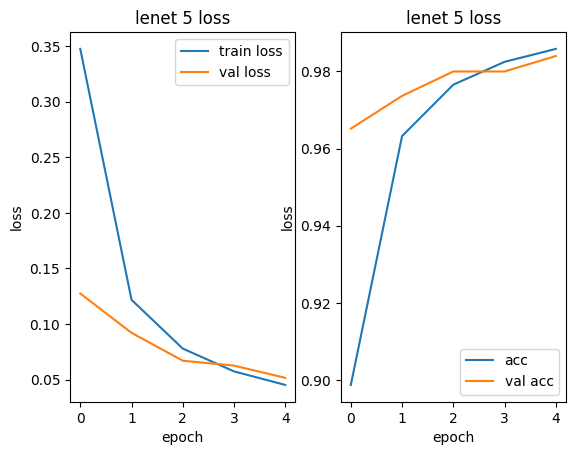

In [ ]:
plt.subplot(1, 2, 1)
plt.plot(history_lenet5.history["loss"], label = "train loss")
plt.plot(history_lenet5.history["val_loss"], label = "val loss")
plt.title("lenet 5 loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lenet5.history["accuracy"], label = "acc")
plt.plot(history_lenet5.history["val_accuracy"], label = "val acc")
plt.title("lenet 5 loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

####Theoy (b)

AlexNet, introduced in 2012, marked a breakthrough in deep learning by winning the ImageNet competition. It is deeper than LeNet-5 and uses ReLU activation, dropout for regularization, and overlapping pooling. It is designed for large-scale image classification tasks and significantly improved performance compared to earlier models.

In [ ]:
(x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()

print("x_train shape: ", x_train_c.shape)
print("y_train shape: ", y_train_c.shape)
print("x_test shape: ", x_test_c.shape)
print("y_test shape: ", y_test_c.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
x_train shape:  (50000, 32, 32, 3)
y_train shape:  (50000, 1)
x_test shape:  (10000, 32, 32, 3)
y_test shape:  (10000, 1)


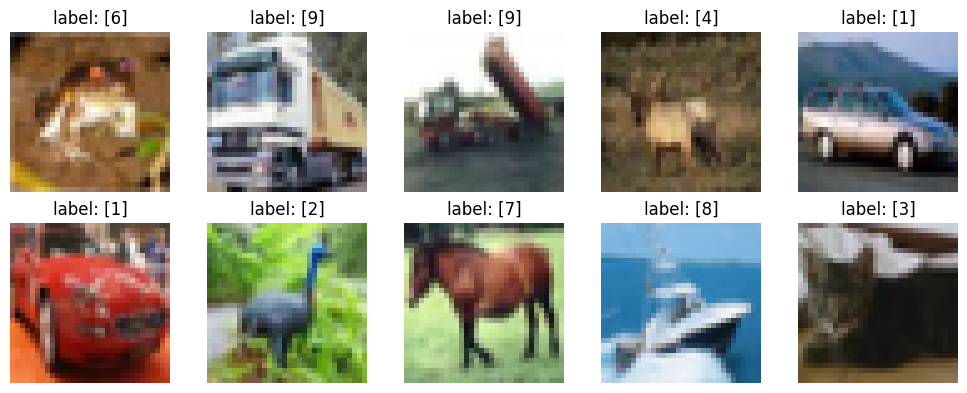

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog' ,'horse', 'ship', 'truck']

plt.figure(figsize = (10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train_c[i], cmap = "gray")
  plt.title(f"label: {y_train_c[i]}")
  plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
train_c_samples = 20000
test_c_samples = 200

x_train_c =  x_train_c[:train_c_samples]
y_train_c = y_train_c[:train_c_samples]

x_test_c = x_test_c[:test_c_samples]
y_test_c = y_test_c[:test_c_samples]

print("subset x_train_c shape: ", x_train_c.shape)
print("subset y_train_c shape: ", y_train_c.shape)

subset x_train_c shape:  (500, 227, 227, 3)
subset y_train_c shape:  (500, 1)


In [ ]:
print("subset x_test_c shape: ", x_test_c.shape)
print("subset y_test_c shape: ", y_test_c.shape)

subset x_test_c shape:  (100, 227, 227, 3)
subset y_test_c shape:  (100, 1)


In [ ]:
x_train_c = tf.image.resize(x_train_c, [227, 227]).numpy()
x_test_c = tf.image.resize(x_test_c, [227, 227]).numpy()

x_train_c = x_train_c / 255.0
x_test_c = x_test_c / 255.0

y_train_c_cat = to_categorical(y_train_c, 10)
y_test_c_cat = to_categorical(y_test_c, 10)

print("new x_train shape: ", x_train_c.shape)
print("new x_test shape: ", x_test_c.shape)
print("new y_train shape: ", y_train_c_cat.shape)
print("new y_test shape: ", y_test_c_cat.shape)

new x_train shape:  (500, 227, 227, 3)
new x_test shape:  (100, 227, 227, 3)
new y_train shape:  (500, 10)
new y_test shape:  (100, 10)


In [ ]:
alexnet = models.Sequential()

alexnet.add(layers.Input(shape = (227, 227, 3)))

alexnet.add(layers.Conv2D(96, kernel_size = (11, 11), activation = 'relu', strides = 4))
alexnet.add(layers.BatchNormalization())
alexnet.add(layers.MaxPooling2D(pool_size = (3, 3), strides = 2))

alexnet.add(layers.Conv2D(256, kernel_size = (5, 5), padding = 'same', activation = 'relu'))
alexnet.add(layers.BatchNormalization())
alexnet.add(layers.MaxPooling2D(pool_size = (3, 3), strides = 2))

alexnet.add(layers.Conv2D(384, kernel_size = (3, 3), padding = 'same', activation = 'relu'))

alexnet.add(layers.Conv2D(384, kernel_size = (3, 3), padding = 'same', activation = 'relu'))

alexnet.add(layers.Conv2D(256, kernel_size = (3, 3), padding = 'same', activation = 'relu'))
alexnet.add(layers.MaxPooling2D(pool_size = (3, 3), strides = 2))

alexnet.add(layers.Flatten())

alexnet.add(layers.Dense(4096, activation = "relu"))
alexnet.add(layers.Dropout(0.5))

alexnet.add(layers.Dense(4096, activation = "relu"))
alexnet.add(layers.Dropout(0.5))

#output
alexnet.add(layers.Dense(10, activation = "softmax"))

In [ ]:
alexnet.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 55, 55, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,323,722 (222.49 MB)

 Trainable params: 58,323,018 (222.48 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
alexnet.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [ ]:
history_alexnet = alexnet.fit(x_train_c, y_train_c_cat, epochs = 3, batch_size = 64, validation_split = 0.1)

Epoch 1/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 840ms/step - accuracy: 0.1022 - loss: 2.3091 - val_accuracy: 0.1400 - val_loss: 2.3000
Epoch 2/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.1222 - loss: 2.3096 - val_accuracy: 0.1400 - val_loss: 2.2963
Epoch 3/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.1244 - loss: 2.3024 - val_accuracy: 0.1400 - val_loss: 2.2983


In [ ]:
test_loss_alex, test_acc_alex = alexnet.evaluate(x_test_c, y_test_c_cat)

print("alexnet test loss: ", test_loss_alex)
print("alexnet test accuracy: ", test_acc_alex)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - accuracy: 0.0600 - loss: 2.3067
alexnet test loss:  2.3067383766174316
alexnet test accuracy:  0.05999999865889549


Text(0, 0.5, 'loss')

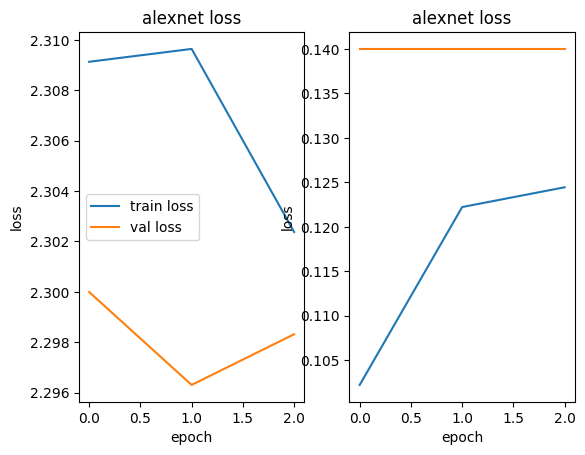

In [ ]:
plt.subplot(1, 2, 1)
plt.plot(history_alexnet.history["loss"], label = "train loss")
plt.plot(history_alexnet.history["val_loss"], label = "val loss")
plt.title("alexnet loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_alexnet.history["accuracy"], label = "acc")
plt.plot(history_alexnet.history["val_accuracy"], label = "val acc")
plt.title("alexnet loss")
plt.xlabel("epoch")
plt.ylabel("loss")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step


/tmp/ipykernel_2207/2767540077.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = class_names[int(y_test_c[i])]


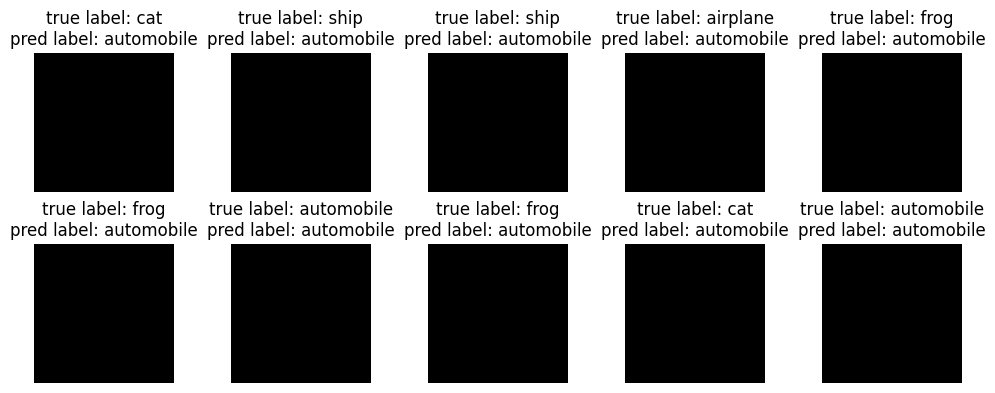

In [ ]:
pred_alex = alexnet.predict(x_test_c[:10])
pred_labels_alex = np.argmax(pred_alex, axis = 1)

plt.figure(figsize = (10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_test_c[i])
  true_label = class_names[int(y_test_c[i])]
  pred_label = class_names[pred_labels_alex[i]]
  plt.title(f"true label: {true_label}\npred label: {pred_label}")
  plt.axis("off")

plt.tight_layout()
plt.show()

####This experiment shows the development of CNN architecture over time from simple architectures like LeNet-5 to more sophisticated architectures like AlexNet. Where LeNet-5 can perform well for basic classification problems, AlexNet outperforms in more complicated tasks through the use of more layers and up-to-date techniques like the Rectified Linear Units (ReLU) and the dropout technique.